## Định nghĩa vấn đề
**Mô tả**
Bộ dữ liệu sonar.all-data chứa các tín hiệu phản hồi (return) thu được từ cảm biến sonar khi chiếu sóng vào các vật thể dưới nước. Mỗi mẫu là một vectơ đặc trưng mô tả biên độ các tín hiệu thu được ở nhiều góc/điểm đo khác nhau. Mục tiêu là phân loại xem vật thể là “đá” (R — rock) hay “đào mìn” (M — mine).

**Dữ liệu vào (Features)**
60 thuộc tính số thực (float): các giá trị biên độ tại các góc/tần số khác nhau (thứ tự đã lưu trong file).
Đặt tên chung: x1, x2, ..., x60 (hoặc giữ nguyên cột số 0..59 nếu đọc không có header).

**Kết quả / Mục tiêu (Target / Goal)**
MEDV tương đương trong housing → ở đây là lớp phân loại nhị phân:
class (cột cuối, index 60):
M = mine (vật thể có dạng hình tròn giống mìn)
R = rock
Mục tiêu: xây dựng mô hình phân loại nhị phân để dự đoán nhãn M hoặc R cho mẫu mới.

## 2. Chuẩn bị bài toán

## a) Tải thư viện

In [1]:
import numpy
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

## b) Tải tập dữ liệu

In [2]:
url = '../data/raw/sonar.all-data.csv'
dataset = read_csv(url, header=None)

## 3. Phân tích khám phá dữ liệu (Exploration Analyze Data - EDA)

## a) Thống kê mô tả

In [ ]:
print(dataset.shape)
set_option('display.max_rows', 500)
print(dataset.dtypes)



(208, 61)
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64
17    float64
18    float64
19    float64
20    float64
21    float64
22    float64
23    float64
24    float64
25    float64
26    float64
27    float64
28    float64
29    float64
30    float64
31    float64
32    float64
33    float64
34    float64
35    float64
36    float64
37    float64
38    float64
39    float64
40    float64
41    float64
42    float64
43    float64
44    float64
45    float64
46    float64
47    float64
48    float64
49    float64
50    float64
51    float64
52    float64
53    float64
54    float64
55    float64
56    float64
57    float64
58    float64
59    float64
60     object
dtype: object
        0       1       2       3       4       5       6       7       8       9   ...      51  \
0   0.0200  0.0371  0.0

Tập dữ liệu bao gồm 208 mẫu với 61 thuộc tính, trong đó có thuộc tính lớp (class attribute). Tất cả các thuộc tính đều có kiểu dữ liệu số thực (float), trong khi thuộc tính lớp được đọc dưới dạng đối tượng (object)

In [10]:
set_option('display.width', 100)
print(dataset.head(20))

       0      1      2      3      4      5      6      7      8      9   ...     51     52  \
0   0.020  0.037  0.043  0.021  0.095  0.099  0.154  0.160  0.311  0.211  ...  0.003  0.006   
1   0.045  0.052  0.084  0.069  0.118  0.258  0.216  0.348  0.334  0.287  ...  0.008  0.009   
2   0.026  0.058  0.110  0.108  0.097  0.228  0.243  0.377  0.560  0.619  ...  0.023  0.017   
3   0.010  0.017  0.062  0.021  0.021  0.037  0.110  0.128  0.060  0.126  ...  0.012  0.004   
4   0.076  0.067  0.048  0.039  0.059  0.065  0.121  0.247  0.356  0.446  ...  0.003  0.005   
5   0.029  0.045  0.028  0.017  0.038  0.099  0.120  0.183  0.210  0.304  ...  0.004  0.001   
6   0.032  0.096  0.132  0.141  0.167  0.171  0.073  0.140  0.208  0.351  ...  0.020  0.025   
7   0.052  0.055  0.084  0.032  0.116  0.092  0.103  0.061  0.146  0.284  ...  0.008  0.012   
8   0.022  0.037  0.048  0.048  0.065  0.059  0.075  0.010  0.068  0.149  ...  0.015  0.013   
9   0.016  0.017  0.035  0.007  0.019  0.067  0.10

các thuộc tính dữ liệu đều nằm trên cùng một thang đo, đảm bảo tính nhất quán

In [11]:
set_option('display.precision', 3)
print(dataset.describe())
print(dataset.groupby(60).size())

            0          1        2        3        4        5        6        7        8        9   \
count  208.000  2.080e+02  208.000  208.000  208.000  208.000  208.000  208.000  208.000  208.000   
mean     0.029  3.844e-02    0.044    0.054    0.075    0.105    0.122    0.135    0.178    0.208   
std      0.023  3.296e-02    0.038    0.047    0.056    0.059    0.062    0.085    0.118    0.134   
min      0.002  6.000e-04    0.002    0.006    0.007    0.010    0.003    0.005    0.007    0.011   
25%      0.013  1.645e-02    0.019    0.024    0.038    0.067    0.081    0.080    0.097    0.111   
50%      0.023  3.080e-02    0.034    0.044    0.062    0.092    0.107    0.112    0.152    0.182   
75%      0.036  4.795e-02    0.058    0.065    0.100    0.134    0.154    0.170    0.233    0.269   
max      0.137  2.339e-01    0.306    0.426    0.401    0.382    0.373    0.459    0.683    0.711   

       ...       50         51         52       53         54         55         56       

Dữ liệu có cùng khoảng giá trị, tuy nhiên giá trị trung bình giữa các thuộc tính khác nhau đáng kể, cho thấy việc chuẩn hóa dữ liệu có thể mang lại lợi ích trong quá trình huấn luyện mô hình. Ngoài ra, phân bố lớp khá cân bằng giữa hai nhãn M (mines) và R (rocks), giúp giảm nguy cơ sai lệch do mất cân bằng dữ liệu.

## b) Trực quan hóa dữ liệu

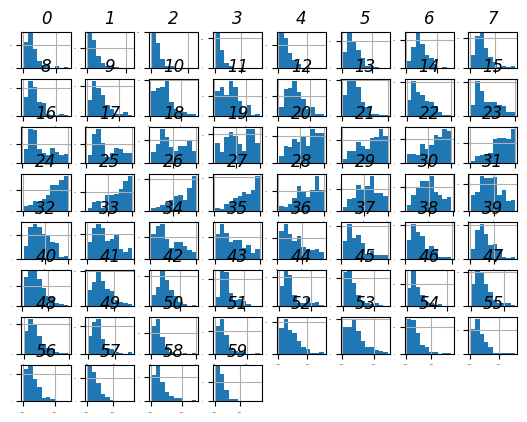

In [6]:
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1)
pyplot.show()

Quan sát cho thấy nhiều thuộc tính có phân phối gần giống Gaussian, trong khi một số khác lại thể hiện dạng phân phối gần với hàm mũ (exponential-like), phản ánh sự đa dạng về đặc tính thống kê trong tập dữ liệu.

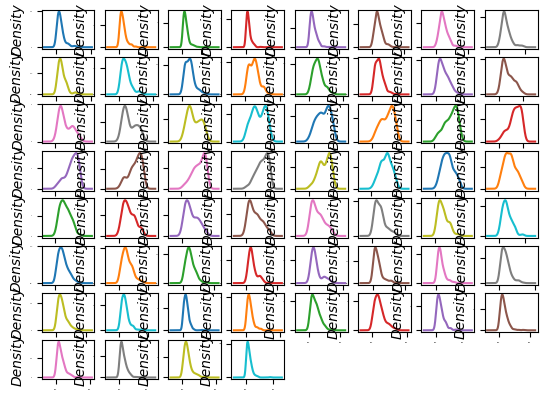

In [7]:
dataset.plot(kind='density', subplots=True, layout=(8,8), sharex=False, legend=False, fontsize=1)
pyplot.show()

Quan sát này cho thấy nhiều thuộc tính có phân phối lệch (skewed distribution). Do đó, việc áp dụng biến đổi lũy thừa (power transform) như Box-Cox transform có thể giúp hiệu chỉnh độ lệch và cải thiện tính phân phối chuẩn của dữ liệu, hỗ trợ mô hình học máy hoạt động hiệu quả hơn.

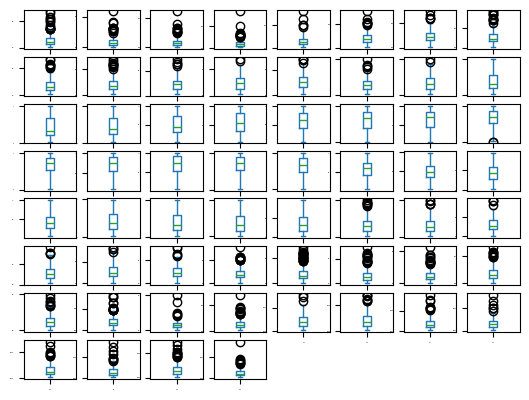

In [8]:
dataset.plot(kind='box', subplots=True, layout=(8,8), sharex=False, sharey=False, fontsize=1)
pyplot.show()

Các thuộc tính thể hiện độ phân tán khá khác nhau, mặc dù thang đo dữ liệu là giống nhau. Điều này cho thấy việc chuẩn hóa dữ liệu có thể mang lại lợi ích, giúp căn chỉnh giá trị trung bình của các thuộc tính và tăng tính ổn định cho quá trình huấn luyện mô hình.

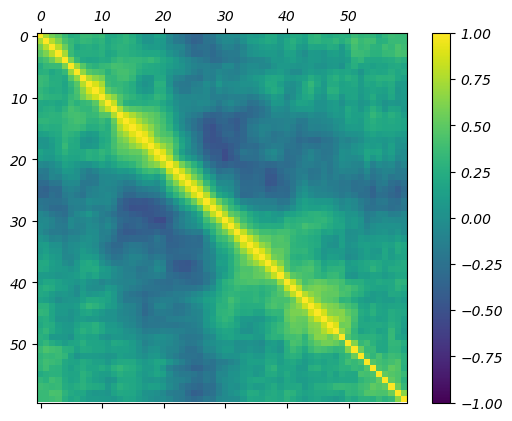

In [12]:
fig = pyplot.figure()
ax = fig.add_subplot(111)
numeric_dataset = dataset.select_dtypes(include=['number'])
cax = ax.matshow(numeric_dataset.corr(), vmin=-1, vmax=1, interpolation='none')
fig.colorbar(cax)
pyplot.show()

Kết quả cho thấy có cấu trúc nhất định trong thứ tự của các thuộc tính. Vùng màu đỏ dọc theo đường chéo cho thấy các thuộc tính liền kề có xu hướng tương quan dương mạnh với nhau, trong khi các mảng màu xanh biểu thị tương quan âm ở mức vừa phải giữa các thuộc tính cách xa nhau hơn. Điều này phù hợp với giả thuyết rằng thứ tự các thuộc tính thể hiện góc đo của cảm biến trong tín hiệu sonar.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from save_images import save_notebook_images, print_save_summary

# Lưu tất cả hình ảnh từ notebook
result = save_notebook_images("EDA.ipynb", output_dir="images")

# In tóm tắt kết quả
print_save_summary(result)


 Hoàn tất: 4 hình ảnh được lưu
 Thư mục: c:\Users\ASUS\Documents\SGU_khai_pha_du_lieu_DDU1231\Thực hành\Connectionist_Bench\EDA\images
 Danh sách file:
   - images\chart_1_01.png
   - images\chart_1_02.png
   - images\chart_1_03.png
   - images\chart_1_04.png
